# Jupyter Notebook

This is a notebook comprising of a Markdown text and `python` code. Markdown is a simple formatting syntax for authoring HTML, PDF, and MS Word documents. For more details on using Markdown, see <https://www.markdownguide.org>.

You can embed an `python` shell like this:

In [5]:
import numpy as np
import pandas as pd

print(1 + 1)
print(np.sin(np.pi / 2))
print("OM 620 Rocks")

2
1.0
OM 620 Rocks


If you haven't already, make sure you have selected the `python` for your notebook before you run individual shells.

## Introductory Example



import

In [4]:
import json

path = '../data/usagov_bitly_data2012-03-16-1331923249.txt'
records = [json.loads(line) for line in open(path, 'rb')]

# []is for for records in vectorized form
# {} is for records in dictionary form

In [ ]:
# Inspecting the entire dataset
records

# Inspecting a single observation
records[0]

# Inspecting a single entry
records[0]['tz']

# running records [0] will run the entire dictionary for the first record, while running records[0]['tz'] will return only the value associated with the 'tz' key in that dictionary.


'America/New_York'

remember the index in python starts from 0

In [7]:
records [0] 

{'a': 'Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKit/535.11 (KHTML, like Gecko) Chrome/17.0.963.78 Safari/535.11',
 'c': 'US',
 'nk': 1,
 'tz': 'America/New_York',
 'gr': 'MA',
 'g': 'A6qOVH',
 'h': 'wfLQtf',
 'l': 'orofrog',
 'al': 'en-US,en;q=0.8',
 'hh': '1.usa.gov',
 'r': 'http://www.facebook.com/l/7AQEFzjSi/1.usa.gov/wfLQtf',
 'u': 'http://www.ncbi.nlm.nih.gov/pubmed/22415991',
 't': 1331923247,
 'hc': 1331822918,
 'cy': 'Danvers',
 'll': [42.576698, -70.954903]}

In [8]:
# Step 1: Extracting all time zones
time_zones = [rec['tz'] for rec in records]


KeyError: 'tz'

the reason this doesn't work is because it assumes there is something in the time zone row has something in it. but in this data set there are some where time zone isn't listed.

In [9]:
# Step 1.1 Extracting all existing time zones
time_zones = [rec['tz'] for rec in records if 'tz' in rec]

this works because logic doesn't include the empty data cells

In [10]:
# Step 2: Defining a count fuction
def get_counts(sequence):
    counts = {}
    for x in sequence:
        if x in counts:
            counts[x] += 1
        else:
            counts[x] = 1
    return counts

get_counts(time_zones)


{'America/New_York': 1251,
 'America/Denver': 191,
 'America/Sao_Paulo': 33,
 'Europe/Warsaw': 16,
 '': 521,
 'America/Los_Angeles': 382,
 'Asia/Hong_Kong': 10,
 'Europe/Rome': 27,
 'Africa/Ceuta': 2,
 'Europe/Madrid': 35,
 'Asia/Kuala_Lumpur': 3,
 'Asia/Nicosia': 1,
 'Europe/London': 74,
 'Pacific/Honolulu': 36,
 'America/Chicago': 400,
 'Europe/Malta': 2,
 'Europe/Lisbon': 8,
 'Europe/Paris': 14,
 'Europe/Copenhagen': 5,
 'America/Mazatlan': 1,
 'Europe/Dublin': 3,
 'Europe/Brussels': 4,
 'America/Vancouver': 12,
 'Europe/Amsterdam': 22,
 'Europe/Prague': 10,
 'Europe/Stockholm': 14,
 'America/Anchorage': 5,
 'Asia/Bangkok': 6,
 'Europe/Berlin': 28,
 'America/Rainy_River': 25,
 'Europe/Budapest': 5,
 'Asia/Tokyo': 37,
 'Europe/Vienna': 6,
 'America/Phoenix': 20,
 'Asia/Jerusalem': 3,
 'Asia/Karachi': 3,
 'America/Bogota': 3,
 'America/Indianapolis': 20,
 'America/Montreal': 9,
 'Asia/Calcutta': 9,
 'Europe/Skopje': 1,
 'Asia/Beirut': 4,
 'Australia/NSW': 6,
 'Chile/Continental': 6,
 

<class 'pandas.DataFrame'>
RangeIndex: 3560 entries, 0 to 3559
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   a            3440 non-null   str    
 1   c            2919 non-null   str    
 2   nk           3440 non-null   float64
 3   tz           3440 non-null   str    
 4   gr           2919 non-null   str    
 5   g            3440 non-null   str    
 6   h            3440 non-null   str    
 7   l            3440 non-null   str    
 8   al           3094 non-null   str    
 9   hh           3440 non-null   str    
 10  r            3440 non-null   str    
 11  u            3440 non-null   str    
 12  t            3440 non-null   float64
 13  hc           3440 non-null   float64
 14  cy           2919 non-null   str    
 15  ll           2919 non-null   object 
 16  _heartbeat_  120 non-null    float64
 17  kw           93 non-null     str    
dtypes: float64(4), object(1), str(13)
memory usage: 500.8+ KB


<Axes: ylabel='tz'>

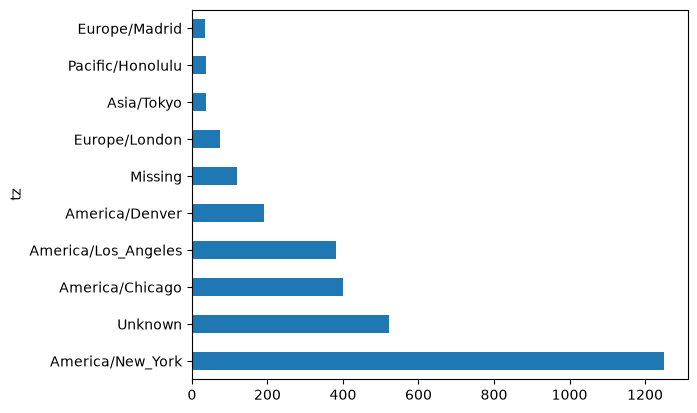

In [ ]:
from pandas import DataFrame, Series
import pandas as pd
frame = DataFrame(records)
frame.info()

tz_counts = frame['tz'].value_counts()
tz_counts

clean_tz = frame['tz'].fillna('Missing')
clean_tz[clean_tz == ''] = 'Unknown'
tz_counts = clean_tz.value_counts()
tz_counts[:10]

tz_counts[:10].plot(kind='barh', rot=0)
# import dataframe and series from pandas library. Create a dataframe from the records list. Use the info() method to get a summary of the dataframe. Use the value_counts() method to count the occurrences of each time zone in the 'tz' column. Fill missing values with 'Missing' and replace empty strings with 'Unknown'. Count the occurrences again and display the top 10 time zones in a horizontal bar plot.. and you don't need to keep repeating it
# if you use a particular function from a particular package all the time, load it, like in this example 'import DataFrame, Series from pandas library' so you don't have to keep typing 'pd.DataFrame' or 'pd.Series' every time you want to use them.
# if you use frame ['tz'] multiple times, you can assign it to a variable like 'clean_tz' and use that variable instead. This makes the code cleaner and easier to read.
# the info() method gives you a summary of the dataframe, including the number of non-null entries in each column, the data type of each column, and the memory usage of the dataframe. This is useful for understanding the structure of your data and identifying any missing values or data type issues.
# the .info() method is a quick way to get a summary of the dataframe, including the number of non-null entries in each column, the data type of each column, and the memory usage of the dataframe. This is useful for understanding the structure of your data and identifying any missing values or data type issues.



using dataframe will put it in frame only format.

In [12]:
# Inspect for visitor type
records[0]['a']

'Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKit/535.11 (KHTML, like Gecko) Chrome/17.0.963.78 Safari/535.11'

In [13]:
records 

[{'a': 'Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKit/535.11 (KHTML, like Gecko) Chrome/17.0.963.78 Safari/535.11',
  'c': 'US',
  'nk': 1,
  'tz': 'America/New_York',
  'gr': 'MA',
  'g': 'A6qOVH',
  'h': 'wfLQtf',
  'l': 'orofrog',
  'al': 'en-US,en;q=0.8',
  'hh': '1.usa.gov',
  'r': 'http://www.facebook.com/l/7AQEFzjSi/1.usa.gov/wfLQtf',
  'u': 'http://www.ncbi.nlm.nih.gov/pubmed/22415991',
  't': 1331923247,
  'hc': 1331822918,
  'cy': 'Danvers',
  'll': [42.576698, -70.954903]},
 {'a': 'GoogleMaps/RochesterNY',
  'c': 'US',
  'nk': 0,
  'tz': 'America/Denver',
  'gr': 'UT',
  'g': 'mwszkS',
  'h': 'mwszkS',
  'l': 'bitly',
  'hh': 'j.mp',
  'r': 'http://www.AwareMap.com/',
  'u': 'http://www.monroecounty.gov/etc/911/rss.php',
  't': 1331923249,
  'hc': 1308262393,
  'cy': 'Provo',
  'll': [40.218102, -111.613297]},
 {'a': 'Mozilla/4.0 (compatible; MSIE 8.0; Windows NT 6.1; WOW64; Trident/4.0; SLCC2; .NET CLR 2.0.50727; .NET CLR 3.5.30729; .NET CLR 3.0.30729; Media Center PC 6.0

In [14]:
# Step 1.1 Extracting all existing time zones
userdest = [rec['a'] for rec in records if 'a' in rec]

In [15]:
userdest = [rec['a'] for rec in records if 'a' in rec]

In [16]:
def get_counts(sequence):
    counts = {}
    for x in sequence:
        if x in counts:
            counts[x] += 1
        else:
            counts[x] = 1
    return counts

get_counts(userdest)

{'Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKit/535.11 (KHTML, like Gecko) Chrome/17.0.963.78 Safari/535.11': 5,
 'GoogleMaps/RochesterNY': 121,
 'Mozilla/4.0 (compatible; MSIE 8.0; Windows NT 6.1; WOW64; Trident/4.0; SLCC2; .NET CLR 2.0.50727; .NET CLR 3.5.30729; .NET CLR 3.0.30729; Media Center PC 6.0; .NET4.0C; .NET4.0E; InfoPath.3)': 1,
 'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_6_8) AppleWebKit/534.52.7 (KHTML, like Gecko) Version/5.1.2 Safari/534.52.7': 52,
 'Mozilla/5.0 (Windows NT 6.1; WOW64) AppleWebKit/535.11 (KHTML, like Gecko) Chrome/17.0.963.79 Safari/535.11': 229,
 'Mozilla/5.0 (Windows NT 5.1) AppleWebKit/535.11 (KHTML, like Gecko) Chrome/17.0.963.79 Safari/535.11': 93,
 'Mozilla/5.0 (Windows NT 6.1; rv:2.0.1) Gecko/20100101 Firefox/4.0.1': 7,
 'Opera/9.80 (X11; Linux zbov; U; en) Presto/2.10.254 Version/12.00': 1,
 'Mozilla/5.0 (Windows NT 6.1; WOW64; rv:10.0.2) Gecko/20100101 Firefox/10.0.2': 309,
 'Mozilla/5.0 (Macintosh; U; Intel Mac OS X 10.4; en-US; rv:1.9.2.27)

<class 'pandas.DataFrame'>
RangeIndex: 3560 entries, 0 to 3559
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   a            3440 non-null   str    
 1   c            2919 non-null   str    
 2   nk           3440 non-null   float64
 3   tz           3440 non-null   str    
 4   gr           2919 non-null   str    
 5   g            3440 non-null   str    
 6   h            3440 non-null   str    
 7   l            3440 non-null   str    
 8   al           3094 non-null   str    
 9   hh           3440 non-null   str    
 10  r            3440 non-null   str    
 11  u            3440 non-null   str    
 12  t            3440 non-null   float64
 13  hc           3440 non-null   float64
 14  cy           2919 non-null   str    
 15  ll           2919 non-null   object 
 16  _heartbeat_  120 non-null    float64
 17  kw           93 non-null     str    
dtypes: float64(4), object(1), str(13)
memory usage: 500.8+ KB


<Axes: ylabel='a'>

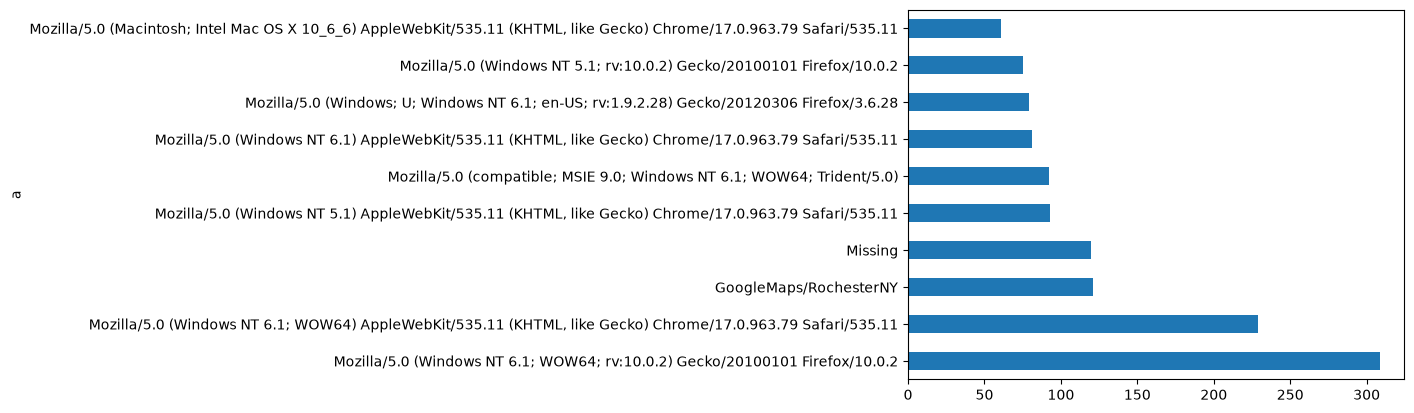

In [18]:
from pandas import DataFrame, Series
import pandas as pd
frame = DataFrame(records)
frame.info()

a_counts = frame['a'].value_counts()
a_counts

clean_a = frame['a'].fillna('Missing')
clean_a[clean_a == ''] = 'Unknown'
a_counts = clean_a.value_counts()
a_counts[:10]

a_counts[:10].plot(kind='barh', rot=0)